In [3]:
from google.colab import drive
import os
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
from scipy.integrate import quad
from scipy import integrate as intg
import sympy as sp
from scipy import stats
from scipy.interpolate import UnivariateSpline
import pandas as pd
from scipy.stats import linregress
from scipy.stats import norm
import matplotlib.colors as mcolors
import os
import seaborn as sns
from matplotlib import pyplot as plt, patches
from re import S

import matplotlib.animation as animation

In [4]:
#Constants/Basic eq's
GM = 4 * np.pi**2

#copying over my eq's from hw3 (numerical integration), they wil be the comparison and building blocks of the leapfrog method
def errorpropdiv(a,b,errA,errB):
    totalerr = (a/b)*(np.sqrt(((errA**2)/(a**2))+((errB**2)/b)))
    return totalerr
#def errorpropsubtract (a,b,errA,errB):
    #totalerr = (a/b)*(np.sqrt(((errA**2)/(a**2))+((errB**2)/b)))
def EulerTest(x0, y0, xn, n):
    h = (xn - x0) / n
    ARRR1, BRRR1 = [x0], [y0]

    # Simple Euler step
    for i in range(n):
        y0 += h * prob1func(x0, y0)
        x0 += h
        ARRR1.append(x0)
        BRRR1.append(y0.copy())

    return ARRR1, BRRR1
def RKtest(x0, y0, xn, n,function):
    h = (xn - x0) / n
    ARRR1, BRRR1 = [x0], [y0]

    for i in range(n):
        k1 = h * function(x0, y0)
        k2 = h * function(x0 + h/2, y0 + k1/2)
        k3 = h * function(x0 + h/2, y0 + k2/2)
        k4 = h * function(x0 + h, y0 + k3)

        k = (k1 + 2*k2 + 2*k3 + k4) / 6
        y0 = y0 + k
        x0 = x0 + h

        ARRR1.append(x0)
        BRRR1.append(y0.copy())

    return ARRR1, BRRR1
#very similar to our other methods, leapfrog just needs to have an extra array to do the "update" inside the loop
def LeapfrogTest(x0, r0, v0, xn, n, a_func):
    h = (xn - x0) / n
    ARRR1, BRRR1, CRRR1 = [x0], [r0], [v0]

    for i in range(n):
        v_half = v0 + a_func(x0, r0) * (h / 2)
        r0 = r0 + v_half * h
        x0 = x0 + h

        v0 = v_half + a_func(x0, r0) * (h / 2)

        ARRR1.append(x0)


        BRRR1.append(r0)
        CRRR1.append(v0)

    return ARRR1, BRRR1, CRRR1

In [6]:
#set the initial values as well as the equations

initialaccel = 9.8
totaltime = 1000
def prob1func(x, y0):
    r3 = (y0[0]**2 + y0[1]**2)**1.5
    return np.array([y0[2], y0[3], -GM*y0[0]/r3, -GM*y0[1]/r3])

def a_func(x, r0):
    r3 = (r0[0]**2 + r0[1]**2)**1.5
    return np.array([-GM*r0[0]/r3, -GM*r0[1]/r3])

t0, tf, steps = 0, 3, 3000
y0_euler = np.array([1.0, 0.0, 0.0, 2*np.pi])
r0_lf = np.array([1.0, 0.0])
v0_lf = np.array([0.0, 2*np.pi])




#Breaking it up into Euler and Leapfrog for plotting later, here we do the integration for both methods over 1000 steps in time
t_E, state_E = EulerTest(t0, y0_euler.copy(), tf, steps)
t_L, r_L, v_L = LeapfrogTest(t0, r0_lf.copy(), v0_lf.copy(), tf, steps, a_func)

state_E = np.array(state_E)
r_mag_E = np.sqrt(state_E[:,0]**2 + state_E[:,1]**2)
v_mag_E = np.sqrt(state_E[:,2]**2 + state_E[:,3]**2)
energy_E = 0.5 * v_mag_E**2 - GM / r_mag_E

r_L, v_L = np.array(r_L), np.array(v_L)
r_mag_L = np.sqrt(r_L[:,0]**2 + r_L[:,1]**2)
v_mag_L = np.sqrt(v_L[:,0]**2 + v_L[:,1]**2)
energy_L = 0.5 * v_mag_L**2 - GM / r_mag_L

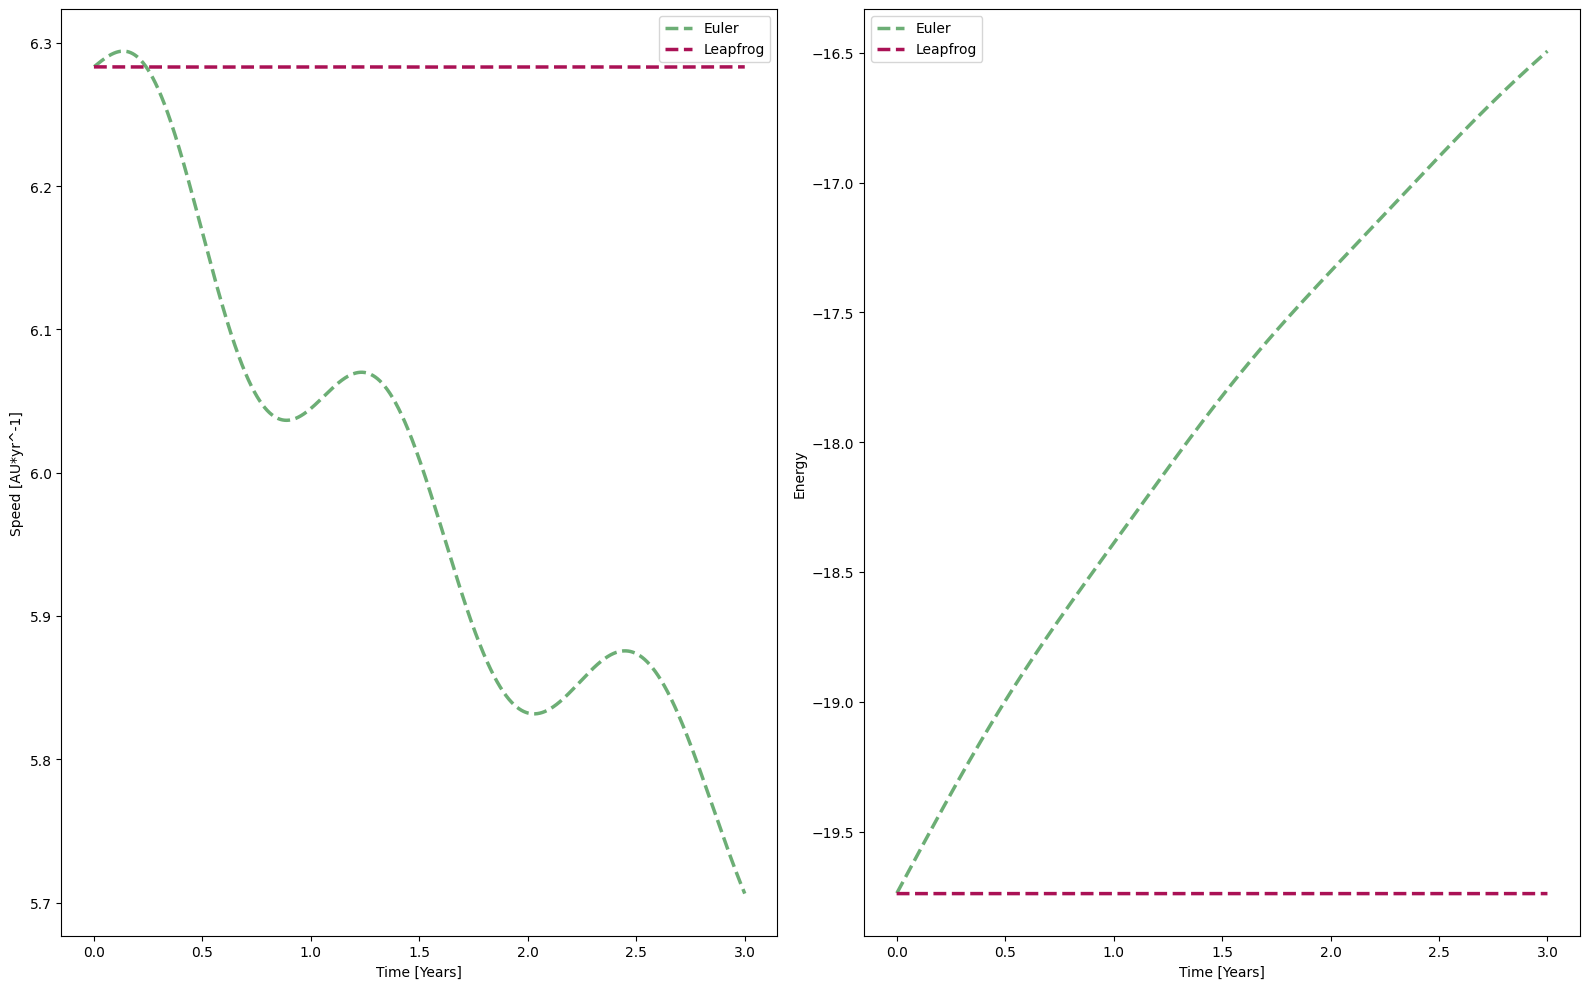

In [30]:
#plotting the values
plt.figure(figsize=(16,10))

plt.subplot(1, 2, 1)
plt.plot(t_E[1:], v_mag_E[1:], label="Euler",c="#6CAE75",linewidth = 2.5,linestyle='--')
plt.plot(t_L, v_mag_L, label="Leapfrog",c="#AA1155",linewidth = 2.5,linestyle='--')

plt.xlabel("Time [Years]")
plt.ylabel("Speed [AU*yr^-1]")


plt.legend()




#plot 2 energy vs time
plt.subplot(1, 2, 2)
plt.plot(t_E[1:], energy_E[1:], label="Euler",c="#6CAE75",linewidth = 2.5,linestyle='--')
plt.plot(t_L, energy_L, label="Leapfrog",c="#AA1155",linewidth = 2.5,linestyle='--')

plt.xlabel("Time [Years]")
plt.ylabel("Energy")

plt.legend()
plt.tight_layout()
plt.show()

In [27]:
""

In [11]:
skip = 10
x_E = state_E[::skip, 0]
y_E = state_E[::skip, 1]
x_L = r_L[::skip, 0]
y_L = r_L[::skip, 1]


fig, ax = plt.subplots(figsize=(16, 10), facecolor='black')
ax.set_facecolor('black')



ax.spines['bottom'].set_color('white')
ax.spines['top'].set_color('white')
ax.spines['right'].set_color('white')
ax.spines['left'].set_color('white')
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')


ax.set_xlabel("x")
ax.set_ylabel("y")



ax.plot(0, 0, 'yo', markersize=15, label="Sun")








#Leapfrog plotting (See the works cited for my mention of the github project i refrenced here, that tutorial was super helpful!)
#

#line_L, = ax.plot([], [], color='cyan', linestyle='-', linewidth=1.5, label="Leapfrog Orbit")
#print (line_L)
line_L, = ax.plot([], [], color='cyan', linestyle='-', linewidth=1.5, label="Leapfrog Orbit")
point_L, = ax.plot([], [], color='cyan', marker='o', markersize=6)





#Euler STuff
line_E, = ax.plot([], [], color='magenta', linestyle='--', linewidth=1.5, label="Euler Orbit")
point_E, = ax.plot([], [], color='magenta', marker='o', markersize=6)

# --- LEGEND ---
# Custom legend on a black background with white text
legend = ax.legend(loc="upper right", facecolor='black', edgecolor='gray', labelcolor='white', framealpha=0.8)


def init():

    line_E.set_data([], [])
    point_E.set_data([], [])
    line_L.set_data([], [])
    point_L.set_data([], [])
    #In case we need to add more later, but we dont need an update line for the sun
    #line_S.set_data([], [])
    #point_S.set_data([], [])

    return line_E, point_E, line_L, point_L

def animate(i):

    line_E.set_data(x_E[:i], y_E[:i])
    line_L.set_data(x_L[:i], y_L[:i])


    point_E.set_data([x_E[i]], [y_E[i]])
    point_L.set_data([x_L[i]], [y_L[i]])

    return line_E, point_E, line_L, point_L
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect('equal')


anim = animation.FuncAnimation(fig, animate, init_func=init,
                               frames=len(x_E), interval=30, blit=True)


#anim.save('TESTORBIT2.gif', writer='pillow', fps=30)
anim.save('TESTORBIT2.gif', fps=10)

plt.close(fig)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Style things, might not include:
#ax.grid(color='gray', linestyle=':', linewidth=0.5, alpha=0.7)


Works Citesd
-----------------------------------------------
[1] https://jakevdp.github.io/blog/2012/08/18/matplotlib-animation-tutorial/
